In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
import kagglehub

path = kagglehub.dataset_download("osamajalilhassan/bone-fracture-dataset")
base_dir  = os.path.join(path, "BoneFractureDataset")
train_dir = os.path.join(base_dir, "training")
test_dir  = os.path.join(base_dir, "testing")
print(base_dir)

Using Colab cache for faster access to the 'bone-fracture-dataset' dataset.
/kaggle/input/bone-fracture-dataset/BoneFractureDataset


In [11]:
IMG = (224, 224)
BATCH = 32

train_ds = keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=42,
    image_size=IMG, batch_size=BATCH)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", seed=42,
    image_size=IMG, batch_size=BATCH)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG, batch_size=BATCH, shuffle=False)

class_names = train_ds.class_names
print(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 8863 files belonging to 2 classes.
Using 7091 files for training.
Found 8863 files belonging to 2 classes.
Using 1772 files for validation.
Found 600 files belonging to 2 classes.
['fractured', 'not_fractured']


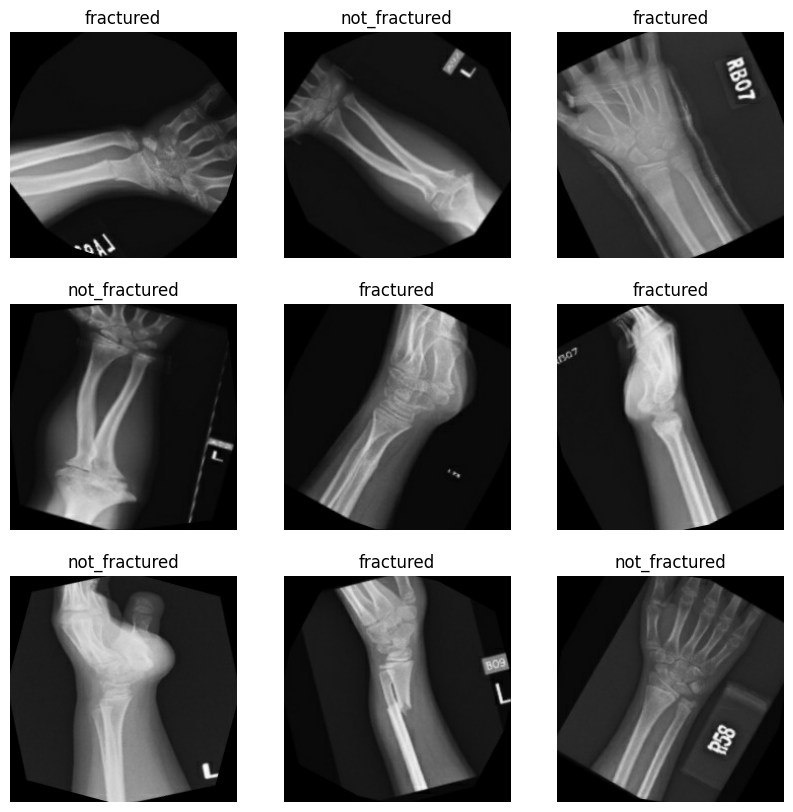

In [12]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [15]:
base = keras.applications.MobileNetV2(

    input_shape=IMG + (3,), include_top=False, weights="imagenet")

base.trainable = False

inputs = keras.Input(shape=IMG + (3,))

x = keras.applications.mobilenet_v2.preprocess_input(inputs)

x = base(x, training=False)

x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dropout(0.3)(x)

outputs = keras.layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(

    optimizer=keras.optimizers.Adam(1e-3),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history = model.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(
        patience=3, restore_best_weights=True)])

Epoch 1/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 44s 143ms/step - accuracy: 0.7196 - loss: 0.5524 - val_accuracy: 0.8335 - val_loss: 0.3821
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8230 - loss: 0.3925 - val_accuracy: 0.8821 - val_loss: 0.3118
Epoch 3/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8507 - loss: 0.3368 - val_accuracy: 0.8995 - val_loss: 0.2769
Epoch 4/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.8636 - loss: 0.3091 - val_accuracy: 0.8854 - val_loss: 0.2751
Epoch 5/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.8759 - loss: 0.2923 - val_accuracy: 0.9142 - val_loss: 0.2374
Epoch 6/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8806 - loss: 0.2834 - val_accuracy: 0.9227 - val_loss: 0.2256
Epoch 7/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8794 - loss: 0.2801 - val_accuracy: 0.9238 - val_loss: 0.2135
Epoch 8/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8828 - loss: 0.2725 -

In [19]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

history_ft = model.fit(
    train_ds, validation_data=val_ds, epochs=8,
    callbacks=[keras.callbacks.EarlyStopping(
        patience=3, restore_best_weights=True)])

Epoch 1/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 31s 93ms/step - accuracy: 0.9961 - loss: 0.0151 - val_accuracy: 0.9972 - val_loss: 0.0133
Epoch 2/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9984 - loss: 0.0083 - val_accuracy: 0.9977 - val_loss: 0.0107
Epoch 3/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9992 - loss: 0.0062 - val_accuracy: 0.9966 - val_loss: 0.0114
Epoch 4/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9990 - loss: 0.0051 - val_accuracy: 0.9977 - val_loss: 0.0072
Epoch 5/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9992 - loss: 0.0044 - val_accuracy: 0.9994 - val_loss: 0.0064
Epoch 6/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9996 - loss: 0.0037 - val_accuracy: 0.9983 - val_loss: 0.0064
Epoch 7/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9997 - loss: 0.0026 - val_accuracy: 0.9983 - val_loss: 0.0061
Epoch 8/8
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9997 - loss: 0.0024 - val_accu

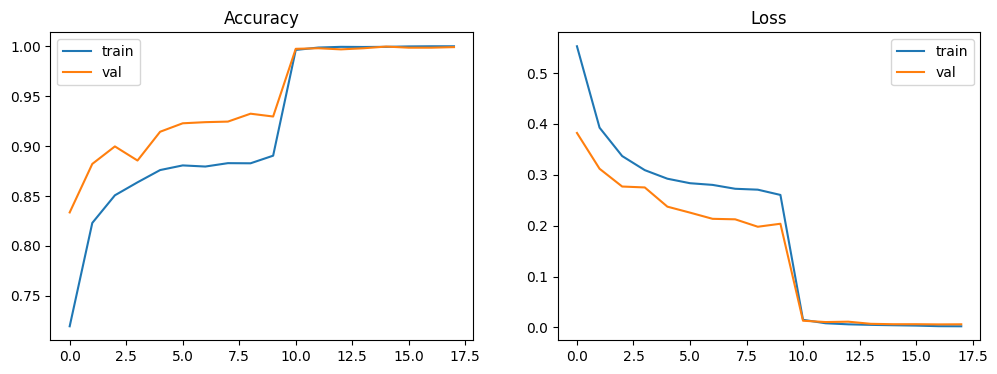

In [20]:
acc  = history.history["accuracy"]     + history_ft.history["accuracy"]
val  = history.history["val_accuracy"] + history_ft.history["val_accuracy"]
loss = history.history["loss"]         + history_ft.history["loss"]
vloss= history.history["val_loss"]     + history_ft.history["val_loss"]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label="train"); plt.plot(val, label="val")
plt.title("Accuracy"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(loss, label="train"); plt.plot(vloss, label="val")
plt.title("Loss"); plt.legend()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 630ms/step - accuracy: 0.7733 - loss: 0.7686
Test accuracy: 0.7733
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step
               precision    recall  f1-score   support

    fractured       0.83      0.78      0.81       360
not_fractured       0.70      0.76      0.73       240

     accuracy                           0.77       600
    macro avg       0.76      0.77      0.77       600
 weighted avg       0.78      0.77      0.77       600



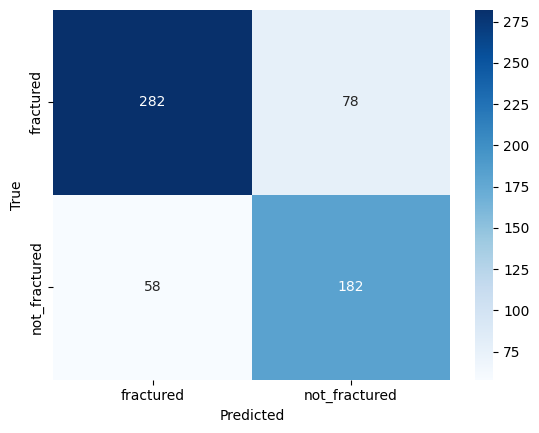

In [21]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.argmax(model.predict(test_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

In [22]:
model.save("fracture_model.keras")

In [23]:
from google.colab import files
files.download("fracture_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving images (4).jfif to images (4).jfif


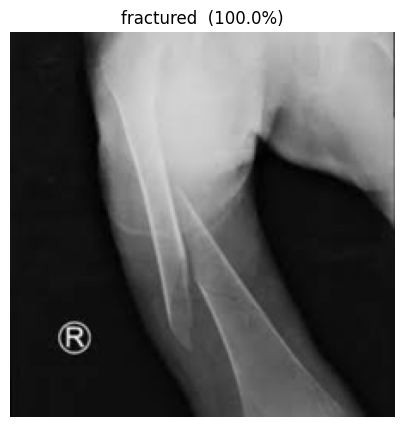

fractured: 100.0%
not_fractured: 0.0%


In [24]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

for fname in uploaded:
    img = Image.open(fname).convert("RGB").resize(IMG)
    arr = np.expand_dims(np.array(img, dtype="float32"), 0)
    pred = model.predict(arr, verbose=0)[0]
    idx = int(np.argmax(pred))

    plt.figure(figsize=(5, 5))
    plt.imshow(img); plt.axis("off")
    plt.title(f"{class_names[idx]}  ({pred[idx] * 100:.1f}%)")
    plt.show()

    for name, p in zip(class_names, pred):
        print(f"{name}: {p * 100:.1f}%")